In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red">ch5. LSTM(Long Short-Term Memory; RNN)으로 영화평 구분하기</font>**

- imdb 5만개 영화 감상평(독립변수) - 부정 / 긍정(종속변수)

# 1. 패키지 import

In [2]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from time import time # 70.1.1부터 현재까지 몇촉 지났는지

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, recall_score, precision_score,f1_score
import pandas as pd


# 2. 하이퍼 파라미터 설정(이 파라미터를 바꾸면 score나 속도에 차이)

In [3]:
MY_WORDS =10000 # imdb 데이터안의 단어 수 
MY_LENGTH =80 # 영화평 단어수 80개 까지만 독립변수(230추천)
MY_EMBED =32 #임베딩 layer의 출력 차원(256추천)
MY_HIDDEN = 64 # LSTM의 units수(128추천)

MY_EPOCH=10 #반복 학습 수 (fit 20추천)
MY_BATCH=200 #매번 가져오는 데이터 수
#불용어 인덱스 설정(빈도수 상위 40개는 제외 : the, a, is등)
SKIP_TOP=40

# 3. 데이터불러오기

In [122]:
(X_train, y_train), (X_test, y_test)=imdb.load_data(num_words=MY_WORDS,
                                                   skip_top=SKIP_TOP
                                                   ) # MY_WORDS(10000)개

In [123]:
print('학습용 데이터 shape:', X_train.shape, y_train.shape)
print('학습용 입력 데이터 샘플:',X_train[0],'-', type(X_train[0]),'-',len(X_train[0]))
print('학습용 타겟 데이터 샘플(0:부정/1:긍정):',y_train[0])

print('시험용 데이터 shape:', X_test.shape, y_test.shape)
print('시험용 입력 데이터 샘플:',X_test[0],'-', type(X_test[0]),'-',len(X_test[0]))
print('시험용 타겟 데이터 샘플(0:부정/1:긍정):',y_test[0])

학습용 데이터 shape: (25000,) (25000,)
학습용 입력 데이터 샘플: [2, 2, 2, 2, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 2, 173, 2, 256, 2, 2, 100, 43, 838, 112, 50, 670, 2, 2, 2, 480, 284, 2, 150, 2, 172, 112, 167, 2, 336, 385, 2, 2, 172, 4536, 1111, 2, 546, 2, 2, 447, 2, 192, 50, 2, 2, 147, 2025, 2, 2, 2, 2, 1920, 4613, 469, 2, 2, 71, 87, 2, 2, 43, 530, 2, 76, 2, 2, 1247, 2, 2, 2, 515, 2, 2, 2, 626, 2, 2, 2, 62, 386, 2, 2, 316, 2, 106, 2, 2, 2223, 5244, 2, 480, 66, 3785, 2, 2, 130, 2, 2, 2, 619, 2, 2, 124, 51, 2, 135, 48, 2, 1415, 2, 2, 2, 2, 215, 2, 77, 52, 2, 2, 407, 2, 82, 2, 2, 2, 107, 117, 5952, 2, 256, 2, 2, 2, 3766, 2, 723, 2, 71, 43, 530, 476, 2, 400, 317, 46, 2, 2, 2, 1029, 2, 104, 88, 2, 381, 2, 297, 98, 2, 2071, 56, 2, 141, 2, 194, 7486, 2, 2, 226, 2, 2, 134, 476, 2, 480, 2, 144, 2, 5535, 2, 51, 2, 2, 224, 92, 2, 104, 2, 226, 65, 2, 2, 1334, 88, 2, 2, 283, 2, 2, 4472, 113, 103, 2, 2, 2, 5345, 2, 178, 2] - <class 'list'> - 218
학습용 타겟 데이터 샘플(0:부정/1:긍정): 1
시험용 데이터 shape: (25000,) (250

In [6]:
#X_train의 길이 및 평균길이
[len(x) for x in X_train[:10]]
np.array([len(x) for x in X_train]).mean()

238.71364

In [7]:
# 부/긍정 갯수 확인
print('학습용 데이터의 긍정 갯수:', y_train.sum())
print('테스트용 데이터의 긍정 갯수:', y_test.sum())

학습용 데이터의 긍정 갯수: 12500
테스트용 데이터의 긍정 갯수: 12500


In [8]:
# 부/긍정 갯수 확인
pd.Series(y_train).value_counts().sort_index()

0    12500
1    12500
dtype: int64

# 4. 문자 단어 -> 정수

In [9]:
word_to_id = imdb.get_word_index() #dict (단어:id값) : 빈도수가 높은 단어를 id앞에 
print(word_to_id['movie'])
print(word_to_id['film'])
print(word_to_id['the'])
# 정수 : 단어 dict
id_to_word={}
for word, id in word_to_id.items():
    id_to_word[id] = word
id_to_word
print(id_to_word[17])
print(id_to_word[19])
print(id_to_word[1])

17
19
1
movie
film
the


In [10]:
# 감성분성에서 필요없는 조사, 관사
print([id_to_word.get(i) for i in range(1, 40)])

['the', 'and', 'a', 'of', 'to', 'is', 'br', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film', 'on', 'not', 'you', 'are', 'his', 'have', 'he', 'be', 'one', 'all', 'at', 'by', 'an', 'they', 'who', 'so', 'from', 'like', 'her', 'or']


In [11]:
msg = 'What a wonderful movie'
msg = msg.lower().split()
# 1: 리뷰시작할때 무조건 추가, 2:1000개문자가 짤려서 잘못 읽어옴, 3:padding처리
data = [1] + [word_to_id.get(m, -1)+3 for m in msg]
print('원 후기 내용 :', msg)
print('encoding된 data :', data)
data_msg = ' '.join([id_to_word.get(d-3, '??') for d in data])
print('data로 추정된 msg :', data_msg)

원 후기 내용 : ['what', 'a', 'wonderful', 'movie']
encoding된 data : [1, 51, 6, 389, 20]
data로 추정된 msg : ?? what a wonderful movie


# 5. 숫자 영화평 -> 자연어 영화평 함수

In [12]:
def decoding(review_num):
    '숫자 영화평을 자연어 영화평으로 바꿔 return'
    decoded= [id_to_word.get(d-3, '??') for d in review_num]
    return ' '.join(decoded)
decoding(X_train[0])

"?? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ?? is an amazing actor and now the same being director ?? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ?? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ?? to the two little boy's that played the ?? of norman and paul they were just brilliant children are often left out of the ?? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't

# 6. 영화평 데이터 처음 5개 길이 출력함수

In [13]:
def show_length(X_train=X_train):
    print('첫 데이터 5개 영화평 단어 길이')
    for i in range(5):
        print(f'{i}번째 길이 : {len(X_train[i])}')
        
show_length()

첫 데이터 5개 영화평 단어 길이
0번째 길이 : 218
1번째 길이 : 189
2번째 길이 : 141
3번째 길이 : 550
4번째 길이 : 147


In [14]:
print('pad sequence 작업전')  # pad sequence 길이를 모두 같게 만드는 작업
show_length(X_train)
show_length(X_test)

pad sequence 작업전
첫 데이터 5개 영화평 단어 길이
0번째 길이 : 218
1번째 길이 : 189
2번째 길이 : 141
3번째 길이 : 550
4번째 길이 : 147
첫 데이터 5개 영화평 단어 길이
0번째 길이 : 68
1번째 길이 : 260
2번째 길이 : 603
3번째 길이 : 181
4번째 길이 : 108


In [15]:
# 영화평 단어길이 최대값과 쵳소값
max(len(x) for x in X_train) , min(len(x) for x in X_train) 

(2494, 11)

# 7. 모든 영화평의 길이를 동일하게(MY_LENGTH만큼)

In [16]:
MY_LENGTH

80

In [17]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [18]:
X_train = pad_sequences(X_train, 
                        maxlen = MY_LENGTH,
                        truncating='post', #80단어 이상일 경우 어디를 짜를지 여부
                       # truncating='pre',
                        padding='pre',  #80단어 미만일 경우 앞에 zero를 붙임
                        #paddubg='post'
                       )
X_test = pad_sequences(X_test, 
                        maxlen = MY_LENGTH,
                        truncating='post', #80단어 이상일 경우 어디를 짜를지 여부
                       # truncating='pre',
                        padding='pre',  #80단어 미만일 경우 앞에 zero를 붙임
                        #paddubg='post'
                       )
show_length(X_train)
show_length(X_test)

첫 데이터 5개 영화평 단어 길이
0번째 길이 : 80
1번째 길이 : 80
2번째 길이 : 80
3번째 길이 : 80
4번째 길이 : 80
첫 데이터 5개 영화평 단어 길이
0번째 길이 : 80
1번째 길이 : 80
2번째 길이 : 80
3번째 길이 : 80
4번째 길이 : 80


In [19]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

# 9. 모델 생성 구현

In [20]:
model =Sequential(name='sequential')
model.add(Embedding(input_dim=MY_WORDS, #임배딩입력: 10000
                    output_dim=MY_EMBED, #임베딩 추력 : 32                   
                   input_length=MY_LENGTH)) # 입력 단어수 :80
# RNN은 장기 과거 시점의 모델 학습이 어려움. 길이가 길어질수록 과거 학습에 어려움이 발생.
# RNN 개선모델 1.LSTM 2.GRU 3.Seq2Seq 4.Attention 
model.add(LSTM(units=MY_HIDDEN, # 출력 units    
              dropout=0.3, #0.2~0.5 각 스텝마다 LSTM셀로 들어가는 X연결 30%를 0으로
               recurrent_dropout=0.2, #0.1~0.3 이전 LSTM에서 다음 LSTM으로 가는 c연결 30%를 0으로
               kernel_regularizer=l2(0.001), #L2 규제
               kernel_initializer='he_normal', #입력 가중치 초기화를 he방법으로 
               recurrent_initializer='orthogonal' # 순환 가중치 초기화
              ))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
#embedding 층 : 파라미터 입력*출력 = 10000*32
# LSTM 층 : 입력*출력 + (64*64)+ unit수(bias) = [(32*64) + (64*64) +64] *4(LSTM은 게이트가 4)
#                                           = (2048 + 4096 + 64)*4
# Dense측 : 입력*출력 +출력 = 64*1+1 =65


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 80, 32)            320000    
                                                                 
 lstm (LSTM)                 (None, 64)                24832     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 344,897
Trainable params: 344,897
Non-trainable params: 0
_________________________________________________________________


# 10. 학습설정 및 학습하기

In [21]:
model.compile(loss='binary_crossentropy',
             optimizer='adam',
             metrics=['acc'])
begin = time() #70.01.01 부터 현재까지의 초수
earlyStopping = EarlyStopping(monitor='val_loss',
                             patience=3,
                             mode='min',
                             restore_best_weights=True, #멈췄을 경우, val_loss가 가장 낮았던 시점의 가중치로 복원
                             verbose=1)
hist=model.fit(X_train, y_train,
               validation_split=0.2, 
               epochs=MY_EPOCH,
               batch_size=MY_BATCH,
               verbose=2,
               callbacks=[earlyStopping])
end=time()
print(f'총학습시간:{end-begin}초')
               

Epoch 1/10
100/100 - 16s - loss: 0.9588 - acc: 0.6820 - val_loss: 0.7430 - val_acc: 0.7946 - 16s/epoch - 165ms/step
Epoch 2/10
100/100 - 13s - loss: 0.5999 - acc: 0.8389 - val_loss: 0.5668 - val_acc: 0.8170 - 13s/epoch - 126ms/step
Epoch 3/10
100/100 - 13s - loss: 0.4326 - acc: 0.8770 - val_loss: 0.5417 - val_acc: 0.8004 - 13s/epoch - 126ms/step
Epoch 4/10
100/100 - 12s - loss: 0.3416 - acc: 0.8942 - val_loss: 0.5036 - val_acc: 0.8120 - 12s/epoch - 122ms/step
Epoch 5/10
100/100 - 14s - loss: 0.2818 - acc: 0.9123 - val_loss: 0.5612 - val_acc: 0.8030 - 14s/epoch - 136ms/step
Epoch 6/10
100/100 - 14s - loss: 0.2483 - acc: 0.9190 - val_loss: 0.5534 - val_acc: 0.7938 - 14s/epoch - 136ms/step
Epoch 7/10
Restoring model weights from the end of the best epoch: 4.
100/100 - 15s - loss: 0.2199 - acc: 0.9273 - val_loss: 0.5492 - val_acc: 0.8004 - 15s/epoch - 149ms/step
Epoch 7: early stopping
총학습시간:96.11105632781982초


# 11. 모델 평가


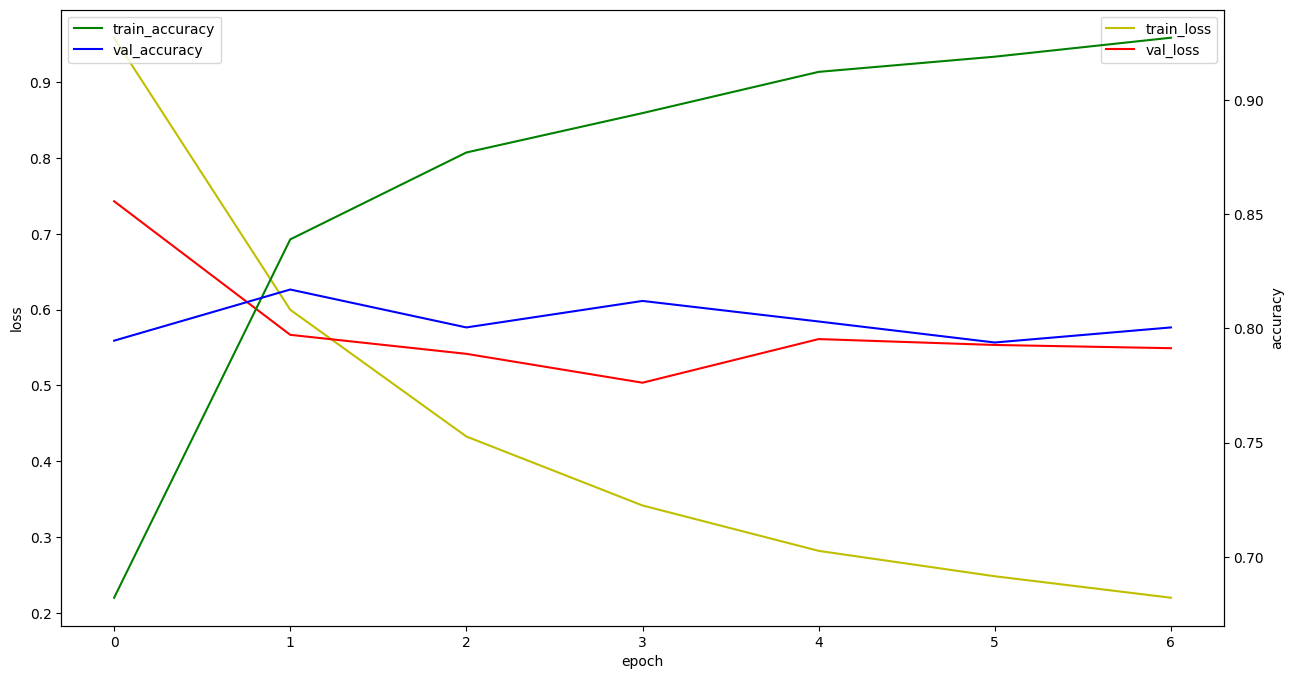

In [24]:
import matplotlib.pyplot as plt
# 학습과정살펴보기 (시각화)
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['acc'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_acc'],'b',label='val_accuracy')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()


In [25]:
loss, acc = model.evaluate(X_test, y_test, 
                           batch_size=MY_BATCH #batch_size 기본값이 32
                          )
print('test데이터의 정확도:',acc)

125/125 [==============================] - 5s 43ms/step - loss: 0.5597 - acc: 0.7861
test데이터의 정확도: 0.7861199975013733


In [28]:
# 혼동행령, recall_score, precision_score, f1_score 계산을 위한 예측값
pred = model.predict(X_test,batch_size=MY_BATCH)
y_hat= (pred>0.5).astype(int)
y_hat

125/125 [==============================] - 5s 41ms/step


array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]])

In [29]:
confusion_matrix(y_test,y_hat)

array([[10087,  2413],
       [ 2934,  9566]], dtype=int64)

In [30]:
pd.crosstab(y_test,y_hat.reshape(-1))

col_0,0,1
row_0,,
0,10087,2413
1,2934,9566


In [34]:
print('recall:', recall_score(y_test,y_hat))
print('precision:', precision_score(y_test,y_hat))
print('f1-score:', f1_score(y_test,y_hat))
print('acc : ',acc)

recall: 0.76528
precision: 0.7985641539360547
f1-score: 0.7815678745046775
acc :  0.7861199975013733


# 12. 모델 사용하기

In [116]:
review = '''It was a heavy topic, but it didn’t miss the fun along the way. 
It seems that actress Lee Jung-eun will undoubtedly have no choice but to win an award for this film.
Tonight I want to go eat malatang with my little daughter It feels light, 
yet it is dense and weighty It really makes me think of my mom while watching it, 
and it’s a movie I want to watch with my family and talk about. 
How long has it been since I last saw a movie like this?@@'''.lower()

In [117]:
import re
review=re.sub('[^a-zA-Z\s]',' ',review).split()

In [124]:
review_num=[1] + [word_to_id.get(word, -1)+3 for word in review]
review_num=[num if (num>40) & (num<10000) else 2 for num in review_num]  #10000초과시 2
print(review_num)

[2, 2, 2, 2, 1185, 2989, 2, 2, 2, 830, 717, 2, 253, 367, 2, 96, 2, 186, 2, 524, 848, 2, 2, 80, 4064, 2, 57, 1099, 2, 2, 1176, 2, 1344, 2, 2, 2, 4487, 2, 181, 2, 140, 1900, 2, 2, 61, 117, 577, 2, 764, 641, 246, 2, 2, 9545, 2, 2, 2, 66, 166, 72, 104, 2, 61, 1633, 137, 149, 2, 2, 2, 590, 2, 2, 2, 181, 2, 106, 2, 61, 223, 2, 740, 44, 89, 196, 47, 2, 77, 237, 2, 236, 219, 2, 2, 2, 2]


In [125]:
input_data= pad_sequences([review_num], 
                maxlen = MY_LENGTH,
                truncating='post', 
                padding='pre' 
                )
input_data.shape

(1, 80)

In [126]:
(model.predict(input_data)>0.5).astype('int')

1/1 [==============================] - 0s 29ms/step


array([[0]])